# Netflix User Analytics Assignment
Dataset: 750 users — demographics, viewing habits, subscription details, and spending patterns.

Goal: analyze user behaviour and apply ML to predict **subscription renewal** (classification) and **monthly spend** (regression).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Part A: Dataset Understanding

### Q1. Load the dataset and display the first five records

In [2]:
df = pd.read_csv('Dataset_2.csv')
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


### Q2. Number of rows and columns

In [3]:
print('Rows, Columns:', df.shape)

Rows, Columns: (750, 10)


### Q3. Display all column names

In [4]:
list(df.columns)

['UserID',
 'Age',
 'Gender',
 'SubscriptionType',
 'WatchHoursPerWeek',
 'DevicesUsed',
 'FavoriteGenre',
 'AdClicks',
 'MonthlySpend',
 'SubscriptionRenewed']

### Q4. Identify numerical and categorical features

In [5]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Numerical  :', numerical)
print('Categorical:', categorical)

Numerical  : ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


### Q5. Check for missing values

In [6]:
df.isnull().sum()

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64

## Part B: Exploratory Data Analysis

### Q6. Average age of users

In [7]:
round(df['Age'].mean(), 2)

np.float64(41.82)

### Q7. Average watch hours per week

In [8]:
round(df['WatchHoursPerWeek'].mean(), 2)

np.float64(14.24)

### Q8. Average monthly spending

In [9]:
round(df['MonthlySpend'].mean(), 2)

np.float64(689.91)

### Q9. Users in each subscription category

In [10]:
df['SubscriptionType'].value_counts()

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64

### Q10. Percentage of users who renewed

In [11]:
renew_pct = (df['SubscriptionRenewed'] == 'Yes').mean() * 100
print(round(renew_pct, 2), '%')

46.27 %


## Part C: Data Preparation

### Q11. Convert categorical features into numerical form
Binary/ordinal columns are mapped directly; `FavoriteGenre` is one-hot encoded.

In [12]:
data = df.copy()
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['SubscriptionType'] = data['SubscriptionType'].map({'Basic': 0, 'Premium': 1, 'VIP': 2})
data['SubscriptionRenewed'] = data['SubscriptionRenewed'].map({'No': 0, 'Yes': 1})
data = pd.get_dummies(data, columns=['FavoriteGenre'], drop_first=True)
data.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,SubscriptionRenewed,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi
0,1001,22,1,0,23,5,13,353,0,True,False,False,False,False
1,1002,55,0,0,9,4,14,317,1,False,True,False,False,False
2,1003,49,0,0,8,3,16,309,0,True,False,False,False,False
3,1004,39,1,1,19,5,45,833,1,False,True,False,False,False
4,1005,38,1,1,23,5,24,804,1,False,False,False,False,True


### Q12. Define feature set (X) and target (y) for renewal prediction

In [13]:
X = data.drop(columns=['UserID', 'SubscriptionRenewed'])
y = data['SubscriptionRenewed']
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (750, 12) | y shape: (750,)


### Q13. Split into training and testing sets (80/20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Train: 600 | Test: 150


## Part D: Decision Tree Classification

### Q14. Train a Decision Tree to predict renewal

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

### Q15. Evaluate using accuracy

In [16]:
dt_acc = accuracy_score(y_test, dt_pred)
print('Decision Tree accuracy:', round(dt_acc, 4))

Decision Tree accuracy: 0.5267


### Q16. Confusion matrix
Rows = actual, columns = predicted. Diagonal = correct predictions; off-diagonal = misclassifications (top-right = false positives, bottom-left = false negatives).

[[44 38]
 [33 35]]


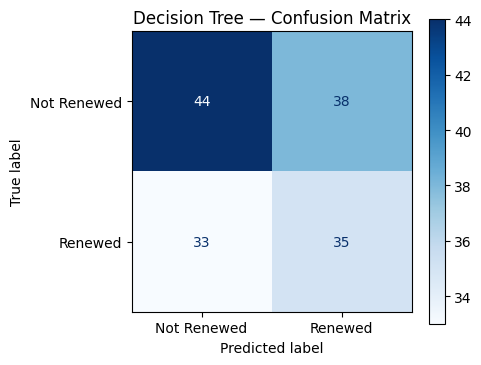

In [17]:
cm = confusion_matrix(y_test, dt_pred)
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Renewed', 'Renewed'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

## Part E: K-Nearest Neighbors (KNN)

### Q17. Train a KNN classifier with K = 5

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print('KNN (K=5) accuracy:', round(knn_acc, 4))

KNN (K=5) accuracy: 0.6333


### Q18. Compare KNN with the Decision Tree

In [19]:
print('Decision Tree:', round(dt_acc, 4))
print('KNN (K=5)    :', round(knn_acc, 4))
print('Better model :', 'KNN' if knn_acc > dt_acc else 'Decision Tree')

Decision Tree: 0.5267
KNN (K=5)    : 0.6333
Better model : KNN


**Which factors influence renewal most?** (Decision Tree feature importances)

In [20]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).round(3)

Age                      0.230
AdClicks                 0.222
MonthlySpend             0.183
WatchHoursPerWeek        0.157
DevicesUsed              0.090
Gender                   0.041
FavoriteGenre_Comedy     0.030
FavoriteGenre_Romance    0.016
FavoriteGenre_Drama      0.013
FavoriteGenre_Sci-Fi     0.010
FavoriteGenre_Horror     0.004
SubscriptionType         0.003
dtype: float64

## Part F: Linear Regression

### Q19. Train a Linear Regression model to predict monthly spending

In [21]:
Xr = data.drop(columns=['UserID', 'MonthlySpend'])
yr = data['MonthlySpend']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(Xr_train, yr_train)
print('R2 score:', round(r2_score(yr_test, lr.predict(Xr_test)), 4))

R2 score: 0.9666


### Q20. Predict monthly spending for a new user and interpret

In [22]:
new_user = Xr_test.iloc[[0]]
pred = lr.predict(new_user)[0]
print('Predicted monthly spend: Rs', round(pred, 2))
print('Actual monthly spend   : Rs', yr_test.iloc[0])

Predicted monthly spend: Rs 835.93
Actual monthly spend   : Rs 853


## Business Reflection Questions

**1. Which factors appear to influence subscription renewal the most?**  
From the Decision Tree importances, Age, AdClicks, MonthlySpend, and WatchHoursPerWeek are the strongest drivers — engagement and spending behaviour matter most.

**2. Why is subscription renewal a classification problem?**  
The target (`SubscriptionRenewed`) is a discrete categorical label (Yes/No), so the model assigns each user to one of two classes.

**3. Why is monthly spending a regression problem?**  
`MonthlySpend` is a continuous numeric value, so we predict a quantity rather than a category.

**4. Which algorithm performed better for renewal prediction?**  
KNN (K=5) achieved higher accuracy (~0.63) than the Decision Tree (~0.53) on the test set.

**5. How could the platform use these predictions to improve customer retention?**  
Netflix can flag users at risk of not renewing (low watch hours, low spend) and target them with personalised recommendations, discounts, or re-engagement campaigns. Spend predictions help with revenue forecasting and tiered offers.

*Note:* both classifiers sit close to the ~54% majority-class baseline, so renewal is only weakly predictable from these features. Feature scaling (important for KNN) and tuning tree depth are reasonable next steps. The regression target is much cleaner (R2 ~ 0.97).